In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
from scipy import stats
from statsmodels.formula.api import ols
from scipy.stats import norm
import numpy as np
from statsmodels.formula.api import ols
from patsy import dmatrix,  build_design_matrices
import seaborn as sns
from statsmodels.gam.api import GLMGam, BSplines
from pygam import GAM, s, te
from pygam import LinearGAM, s, l, PoissonGAM, f, InvGaussGAM
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import STL
from prophet import Prophet
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.seasonal import MSTL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
url = "https://raw.githubusercontent.com/LexoBrunett/STAT408_LexoBrunett/main/Datasets/gala.csv"
gala = pd.read_csv(url, index_col=0)

In [3]:
gala.head()
gala.describe()

,Endemics,Area,Elevation,Nearest,Scruz,Adjacent
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,26.100000,261.708667,368.033333,10.060000,56.976667,261.098333
std,27.331111,864.110519,421.604937,14.274636,68.032334,864.518967
min,0.000000,0.010000,25.000000,0.200000,0.000000,0.030000
25%,7.250000,0.257500,97.750000,0.800000,11.025000,0.520000
50%,18.000000,2.590000,192.000000,3.050000,46.650000,2.590000
75%,32.250000,59.237500,435.250000,10.025000,81.075000,59.237500
max,95.000000,4669.320000,1707.000000,47.400000,290.200000,4669.320000


In [4]:
gala['LogArea'] = np.log(gala['Area'])

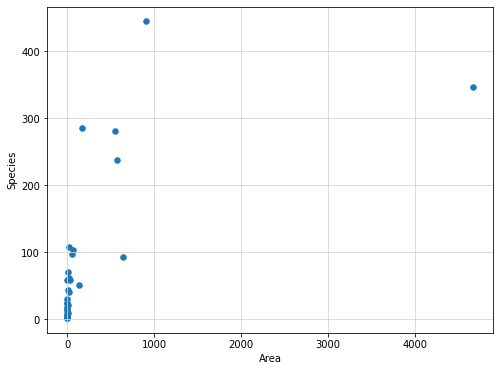

In [5]:
plt.figure(figsize=(8,6))
plt.grid(True, color="lightgray")
plt.scatter(gala['Area'],gala.index, s=30)
plt.xlabel('Area')
plt.ylabel('Species')
plt.show()

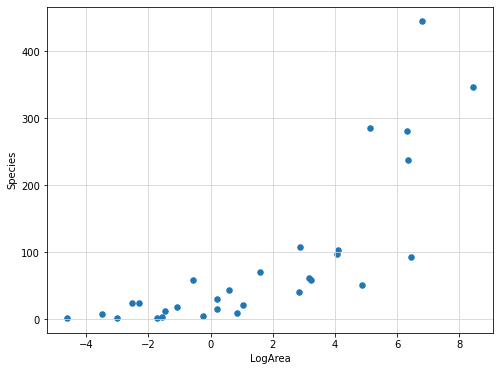

In [6]:
plt.figure(figsize=(8,6))
plt.grid(True, color="lightgray")
plt.scatter(gala['LogArea'], gala.index, s=30)
plt.xlabel('LogArea')
plt.ylabel('Species')
plt.show()

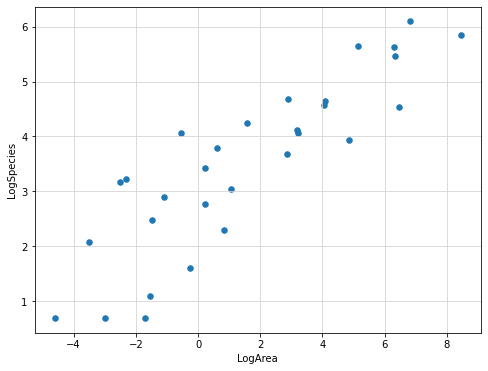

In [7]:
gala['LogSpecies'] = np.log(gala.index)
plt.figure(figsize=(8,6))
plt.grid(True, color="lightgray")
plt.scatter(gala['LogArea'],gala['LogSpecies'], s=30)
plt.xlabel('LogArea')
plt.ylabel('LogSpecies')
plt.show()

We can clearly see that the first two models are not appropriate because the relationships between $S_i$ and $A_i$, and between $S_i$ and $\log(A_i)$, are not linear. In contrast, the relationship between $\log(S_i)$ and $\log(A_i)$ appears approximately linear. Therefore, a linear model is more appropriate for the log-transformed variables. Below, we fit this model and assess whether its assumptions are satisfied.

In [8]:
lm_log_log = ols('LogSpecies ~ LogArea', data = gala).fit()
lm_log_log.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             LogSpecies   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.748
Method:                 Least Squares   F-statistic:                     87.27
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           4.23e-10
Time:                        18:41:04   Log-Likelihood:                -34.240
No. Observations:                  30   AIC:                             72.48
Df Residuals:                      28   BIC:                             75.28
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9037      0.157     18.484      0.000       2.582       3.225
LogArea        0.3886      0.042      9.342      0.000       0.303       0.474
==============================================================================
Omnibus:                        0.893   Durbin-Watson:                   2.776
Prob(Omnibus):                  0.640   Jarque-Bera (JB):                0.839
Skew:                          -0.180   Prob(JB):                        0.657
Kurtosis:                       2.264   Cond. No.                         4.20
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

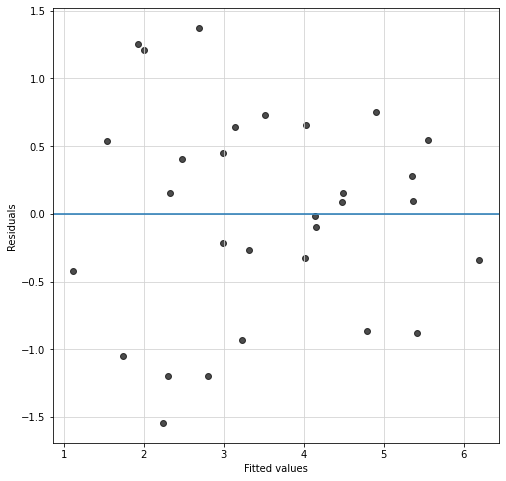

In [9]:
plt.figure(figsize=(8,8))
plt.grid(True, color="lightgray")
plt.scatter(lm_log_log.fittedvalues, lm_log_log.resid, alpha=0.7, color='black')
plt.xlabel('Fitted values')
plt.axhline(0)
plt.ylabel('Residuals')
plt.show()

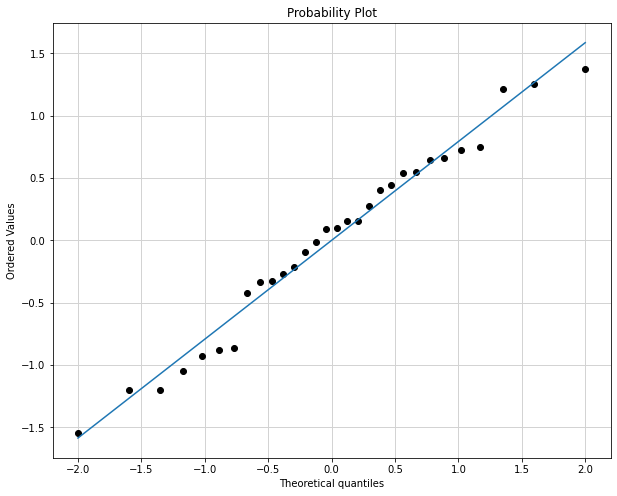

In [10]:
plt.figure(figsize=(10,8))
plt.grid(color='lightgray', linestyle='-', linewidth=1)
stats.probplot(lm_log_log.resid, dist="norm", plot=plt)
plt.gca().get_lines()[0].set_markerfacecolor('black')       # Scatter points
plt.gca().get_lines()[0].set_markeredgecolor('black')   # Scatter points
plt.gca().get_lines()[1].set_color('tab:blue')  
plt.show()

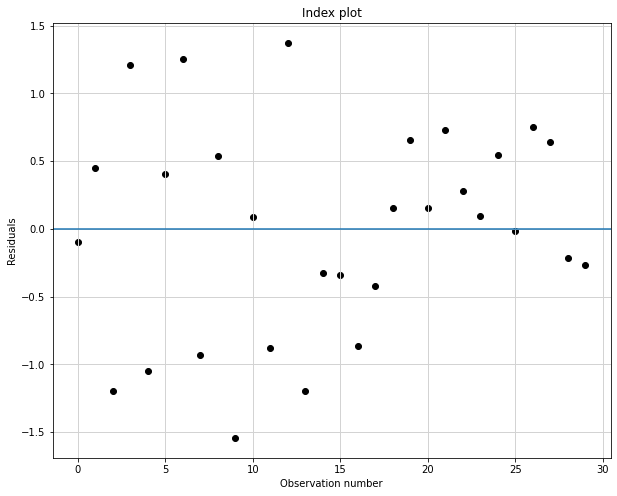

In [11]:
plt.figure(figsize=(10,8))    
plt.grid(color='lightgray', linestyle='-', linewidth=1)
for index, residual in enumerate(lm_log_log.resid):
    plt.scatter(index,residual, color='black')
plt.xlabel('Observation number')
plt.ylabel('Residuals')
plt.title('Index plot')
plt.axhline(0, c='tab:blue')
plt.show()

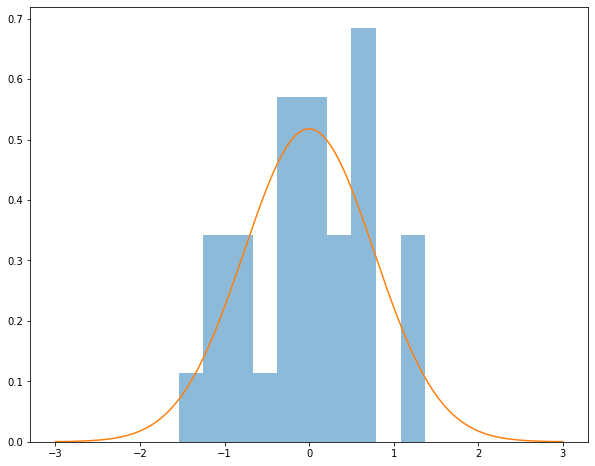

In [12]:
mu = lm_log_log.resid.mean()
sigma = lm_log_log.resid.std(ddof=1)

x = np.linspace(-3, 3, 200)
y = norm.pdf(x, loc = mu, scale = sigma)
plt.figure(figsize=(10,8))
plt.hist(lm_log_log.resid, density='True', alpha=0.5)
plt.plot(x, y)
plt.show()

The assumptions look like they are fairly well met, suggesting that this is a reasonable model for the data-generating process.

Importantly, this model is a *linear model*, but for the transformed response, $\log(S_i)$, and for the transformed predictor, $\log(A_i)$. This brings up an important point, namely that we can use a linear modeling framework to describe non-linear relationships. By linear model framework, we mean that we have a model where the response variable can be written as a “linear combination” of parameters and predictor variables (i.e., a weighted sum of the predictor variables).

$$
Y_i = \beta_0 + X_{i,1}\beta_1 + X_{i,2}\beta_2 + \cdots + \epsilon_i
$$

We can accommodate non-linear relationships within a linear models framework by using:

- Transformations of $X$ or $Y$ or both (e.g., $\log(X)$, $\sqrt{Y}$, $\exp(X)$).
- Polynomials (e.g., $X$ plus $X^2$) as predictors in our model.
- Splines or piecewise polynomials that are unique to different segments of the data.

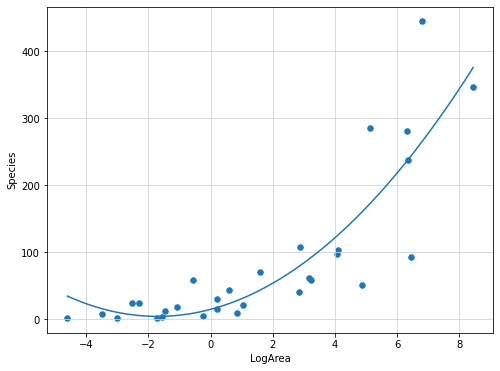

In [13]:
x = gala['LogArea']
y = gala.index

coefficients = np.polyfit(x, y, deg = 2) # deg = 2 because it should match the highest exponent and it is 2 for a quadratic function
my_model = np.poly1d(coefficients)
myline = np.linspace(x.min(), x.max(), 100)

plt.figure(figsize=(8,6))
plt.grid(True, color="lightgray")
plt.scatter(x, y, s=30)
plt.xlabel('LogArea')
plt.ylabel('Species')
plt.plot(myline, my_model(myline))
plt.show()

If we look at the relationship between species and log(Area) (middle panel of Figure 4.2), it appears that a quadratic function might describe the mean species-area curve well. How can we fit this model using lm? One intuitive option would be to create a new “predictor” variable in our data set – the square of logarea and add this predictor to the linear model:

In [14]:
gala['LogAreaSq'] = gala['LogArea']**2
gala_model = gala.reset_index()
polynomial_reg = ols(
    'Species ~ LogArea + I(LogAreaSq)',
    data=gala_model
).fit()
polynomial_reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Species   R-squared:                       0.754
Model:                            OLS   Adj. R-squared:                  0.736
Method:                 Least Squares   F-statistic:                     41.49
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           5.83e-09
Time:                        18:41:05   Log-Likelihood:                -163.25
No. Observations:                  30   AIC:                             332.5
Df Residuals:                      27   BIC:                             336.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       14.8356     14.140      1.049      0.303     -14.177      43.849
LogArea         12.2771      4.645      2.643      0.014       2.747      21.807
I(LogAreaSq)     3.5983      0.922      3.903      0.001       1.707       5.490
==============================================================================
Omnibus:                        9.533   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.009   Jarque-Bera (JB):               15.257
Skew:                           0.471   Prob(JB):                     0.000487
Kurtosis:                       6.364   Cond. No.                         29.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [15]:
polynomial_reg.model.exog[:6]

array([[ 1.        ,  3.22246936, 10.38430878],
       [ 1.        ,  0.21511138,  0.04627291],
       [ 1.        , -1.56064775,  2.43562139],
       [ 1.        , -2.30258509,  5.30189811],
       [ 1.        , -2.99573227,  8.97441185],
       [ 1.        , -1.07880966,  1.16383029]])

#### Splines ####

In [16]:
gala_log_area = gala['LogArea']
gala_log_area1 = np.where(gala['LogArea'] < 1, 0 , gala['LogArea']-1)
gala_log_area42 = np.where(gala['LogArea'] < 4.2, 0 , gala['LogArea'] - 4.2)

In [17]:
gala_log_area1

array([2.22246936, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       3.06508738, 5.45282153, 0.        , 0.        , 1.85359251,
       7.44876873, 3.86360366, 0.        , 3.08698421, 1.88759011,
       0.        , 0.5871923 , 5.3128594 , 5.34971575, 5.80663023,
       2.18138162, 4.14119561, 0.        , 0.        , 0.04731899])

In [18]:
gala_log_area42

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 2.25282153, 0.        , 0.        , 0.        ,
       4.24876873, 0.66360366, 0.        , 0.        , 0.        ,
       0.        , 0.        , 2.1128594 , 2.14971575, 2.60663023,
       0.        , 0.94119561, 0.        , 0.        , 0.        ])

In [19]:
spline_model = ols(
    'Species ~ LogArea + gala_log_area1 + gala_log_area42',
    data=gala_model
).fit()
spline_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Species   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     29.25
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           1.73e-08
Time:                        18:41:05   Log-Likelihood:                -162.17
No. Observations:                  30   AIC:                             332.3
Df Residuals:                      26   BIC:                             338.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          24.1961     16.996      1.424      0.166     -10.739      59.131
LogArea             4.7987      8.582      0.559      0.581     -12.841      22.439
gala_log_area1     17.9110     18.373      0.975      0.339     -19.854      55.676
gala_log_area42    44.7738     22.726      1.970      0.060      -1.940      91.487
==============================================================================
Omnibus:                        9.669   Durbin-Watson:                   2.110
Prob(Omnibus):                  0.008   Jarque-Bera (JB):               18.981
Skew:                           0.287   Prob(JB):                     7.56e-05
Kurtosis:                       6.854   Cond. No.                         13.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [20]:
#so how is y formed? 
beta1 = spline_model.params.LogArea
beta2 = spline_model.params.gala_log_area1
beta3 = spline_model.params.gala_log_area42
intercept = spline_model.params.Intercept

y = intercept  + beta1 * gala_model['LogArea'] + beta2 * gala_log_area1 + beta3 * gala_log_area42

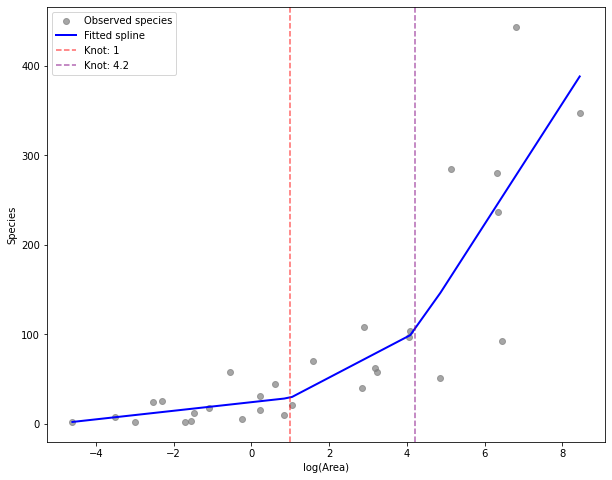

In [21]:
gala_model['y_hat'] = spline_model.predict(gala_model['LogArea'])

# Sort x-values for drawing the fitted line
plot_data = gala_model.sort_values("LogArea")
#he values in y_hat are not sorted independently—they remain matched with their corresponding LogArea observations. That matching is necessary for plotting the fitted line correctly.
plt.figure(figsize=(10,8))
plt.scatter(
    gala_model["LogArea"],
    gala_model["Species"],
    color="gray",
    alpha=0.7,
    label="Observed species"
)

plt.plot(
    plot_data["LogArea"],
    plot_data['y_hat'],
    color="blue",
    linewidth=2,
    label="Fitted spline"
)

# Display knot locations
plt.axvline(1, color="red", linestyle="--", alpha=0.6, label="Knot: 1")
plt.axvline(4.2, color="purple", linestyle="--", alpha=0.6, label="Knot: 4.2")

plt.xlabel("log(Area)")
plt.ylabel("Species")
plt.legend()
plt.show()

#### Natural Cubic Regression Splines ####

Assume that $1$, $4.2$, and $9.3$ are three interior knots:

$$
\xi_1=1,\qquad \xi_2=4.2,\qquad \xi_3=9.3.
$$

A natural spline also requires two boundary knots. For this example, suppose they are

$$
a=0
\qquad\text{and}\qquad
b=12.
$$

If boundary knots are not specified, R and Python generally determine them from the range of the observed predictor.

## Unrestricted cubic-spline basis

Before applying the natural-spline constraints, a cubic spline with three interior knots can be constructed from the basis functions

$$
1,\quad
x,\quad
x^2,\quad
x^3,\quad
(x-1)^3_+,\quad
(x-4.2)^3_+,\quad
(x-9.3)^3_+.
$$

The truncated cubic function is defined as

$$
(x-\xi)^3_+
=
\begin{cases}
0, & x<\xi,\\[4pt]
(x-\xi)^3, & x\geq\xi.
\end{cases}
$$

Therefore, row $i$ of the unrestricted cubic-spline design matrix is

$$
\mathbf{x}_i
=
\left[
1,\;
x_i,\;
x_i^2,\;
x_i^3,\;
(x_i-1)^3_+,\;
(x_i-4.2)^3_+,\;
(x_i-9.3)^3_+
\right].
$$

For example, if $x_i=5$, then

$$
(x_i-1)^3_+
=
(5-1)^3
=
64,
$$

$$
(x_i-4.2)^3_+
=
(5-4.2)^3
=
0.8^3
=
0.512,
$$

and

$$
(x_i-9.3)^3_+
=
0,
$$

because $5<9.3$.

The corresponding design-matrix row is therefore

$$
\mathbf{x}_i
=
\left[
1,\;
5,\;
25,\;
125,\;
64,\;
0.512,\;
0
\right].
$$

With $K=3$ interior knots, the unrestricted cubic-spline design matrix has

$$
1+3+K
=
1+3+3
=
7
$$

columns.

These are

$$
\underbrace{1}_{\text{intercept}},
\qquad
\underbrace{x,x^2,x^3}_{\text{global polynomial terms}},
\qquad
\underbrace{
(x-\xi_1)^3_+,
(x-\xi_2)^3_+,
(x-\xi_3)^3_+
}_{\text{knot terms}}.
$$

## Natural-spline restrictions

A natural cubic spline imposes the condition that the fitted relationship is linear beyond the boundary knots.

Equivalently, its second derivative must equal zero at the boundaries:

$$
f''(a)=0
\qquad\text{and}\qquad
f''(b)=0.
$$

In this example:

$$
f''(0)=0
\qquad\text{and}\qquad
f''(12)=0.
$$

These two restrictions remove two degrees of freedom from the unrestricted cubic spline.

Therefore, the natural spline has

$$
7-2=5
$$

total design-matrix columns:

$$
\underbrace{1}_{\text{intercept}}
+
\underbrace{4}_{\text{spline basis columns}}
=
5.
$$

## One possible natural-spline basis

There are many valid ways to represent the same natural-spline function space.

One possible basis is

$$
B_1(x)=x,
$$

$$
B_2(x)
=
(x-1)^3_+
-
\frac{12-1}{12-0}x^3,
$$

$$
B_3(x)
=
(x-4.2)^3_+
-
\frac{12-4.2}{12-0}x^3,
$$

and

$$
B_4(x)
=
(x-9.3)^3_+
-
\frac{12-9.3}{12-0}x^3.
$$

After simplifying the fractions:

$$
B_1(x)=x,
$$

$$
B_2(x)
=
(x-1)^3_+
-
\frac{11}{12}x^3,
$$

$$
B_3(x)
=
(x-4.2)^3_+
-
\frac{7.8}{12}x^3,
$$

and

$$
B_4(x)
=
(x-9.3)^3_+
-
\frac{2.7}{12}x^3.
$$

These functions combine the original $x^3$ term with the truncated cubic terms. This is how the natural-spline boundary restrictions reduce the number of required columns.

## Complete natural-spline design matrix

For observations $x_1,x_2,\ldots,x_n$, the complete design matrix is

$$
\mathbf{X}
=
\begin{bmatrix}
1 & B_1(x_1) & B_2(x_1) & B_3(x_1) & B_4(x_1)\\
1 & B_1(x_2) & B_2(x_2) & B_3(x_2) & B_4(x_2)\\
1 & B_1(x_3) & B_2(x_3) & B_3(x_3) & B_4(x_3)\\
\vdots & \vdots & \vdots & \vdots & \vdots\\
1 & B_1(x_n) & B_2(x_n) & B_3(x_n) & B_4(x_n)
\end{bmatrix}.
$$

Its dimensions are

$$
n\times5.
$$

Each row represents one observation, and each column represents one basis function.

## Coefficients and predictions

The regression coefficient vector is

$$
\boldsymbol{\beta}
=
\begin{bmatrix}
\beta_0\\
\beta_1\\
\beta_2\\
\beta_3\\
\beta_4
\end{bmatrix}.
$$

The complete vector of fitted values is

$$
\hat{\mathbf{y}}
=
\mathbf{X}\boldsymbol{\beta}.
$$

For observation $i$, the fitted value is

$$
\hat{y}_i
=
\beta_0
+
\beta_1B_1(x_i)
+
\beta_2B_2(x_i)
+
\beta_3B_3(x_i)
+
\beta_4B_4(x_i).
$$

The individual coefficients normally do not have simple slope interpretations. The important quantity is the curve produced by adding all the weighted basis functions.


```


In [22]:
spline_model = ols(
    "Species ~ cr(LogArea, df=3)-1", # cr = cubic regression line
    data=gala_model
).fit()
spline_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Species   R-squared:                       0.756
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                     41.81
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           5.39e-09
Time:                        18:41:06   Log-Likelihood:                -163.16
No. Observations:                  30   AIC:                             332.3
Df Residuals:                      27   BIC:                             336.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
cr(LogArea, df=3)[0]    29.6065     34.106      0.868      0.393     -40.373      99.586
cr(LogArea, df=3)[1]    26.7466     15.837      1.689      0.103      -5.748      59.241
cr(LogArea, df=3)[2]   362.5437     34.972     10.367      0.000     290.788     434.300
==============================================================================
Omnibus:                        8.879   Durbin-Watson:                   2.057
Prob(Omnibus):                  0.012   Jarque-Bera (JB):               15.155
Skew:                           0.313   Prob(JB):                     0.000512
Kurtosis:                       6.425   Cond. No.                         2.85
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [23]:

q33, q67 = np.quantile(
    gala_model["LogArea"],
    [0.33, 0.67]
)

basis_formula = (
    f"cr(LogArea, knots=({q33}, {q67}), "
    "constraints='center') - 1"
)

basis = dmatrix(
    basis_formula,
    data=gala_model,
    return_type="dataframe"
)

basis.columns = ["S1", "S2", "S3"]

Patsy chooses the required knot locations based on the distribution of LogArea.(even quantiles but we can pass knots )

In [24]:
model_formula = (
    f"Species ~ cr(LogArea, knots=({q33}, {q67}), "
    "constraints='center')"
)

spline_model = ols(
    model_formula,
    data=gala_model
).fit()

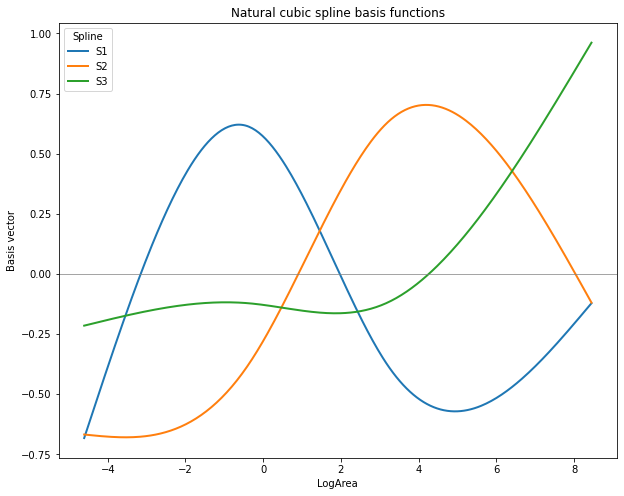

In [25]:
q33, q67 = np.quantile(
    gala_model["LogArea"],
    [0.33, 0.67]
)

# Build basis using the original data
basis = dmatrix(
    f"""cr(
        LogArea,
        knots=({q33}, {q67}),
        constraints='center'
    ) - 1""",
    data=gala_model,
    return_type="dataframe"
)

# Dense x-grid for smooth curves
grid = pd.DataFrame({
    "LogArea": np.linspace(
        gala_model["LogArea"].min(),
        gala_model["LogArea"].max(),
        300
    )
})

# Apply exactly the same basis transformation to the grid
basis_grid = build_design_matrices(
    [basis.design_info],
    grid
)[0]

# Convert to a regular DataFrame
basis_plot = pd.DataFrame(
    np.asarray(basis_grid),
    columns=["S1", "S2", "S3"]
)

basis_plot["LogArea"] = grid["LogArea"]

# Wide to long format
basis_long = basis_plot.melt(
    id_vars="LogArea",
    value_vars=["S1", "S2", "S3"],
    var_name="Spline",
    value_name="BasisVector"
)

# Plot
plt.figure(figsize=(10,8))
sns.lineplot(
    data=basis_long,
    x="LogArea",
    y="BasisVector",
    hue="Spline",
    linewidth=2
)

plt.axhline(0, color="gray", linewidth=0.7)
plt.xlabel("LogArea")
plt.ylabel("Basis vector")
plt.title("Natural cubic spline basis functions")
plt.show()

The shape of a spline can be controlled by carefully choosing the number of knots and their exact locations in order to allow greater flexibility where the trend appears to be changing quickly, while avoiding overfitting in regions where the trend changes little. We could, in principle, compare models (e.g., using AIC) that have varying numbers of knots, or different knot locations. The danger here is that we would open the door to a wide range of possible models, increasing the chances we would overfit our data. Further, proper accounting of model-selection uncertainty associated with such data-driven processes can be challenging

 #### Generalized additive models (GAMS) ####

In [26]:
X = gala_model[["LogArea"]]
y = gala_model["Species"]

gam_smooth = LinearGAM(s(0, n_splines=10)).fit(X, y)
gam_linear = LinearGAM(l(0)).fit(X, y)

print(gam_smooth.summary())
print(gam_linear.summary())

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      4.6221
Link Function:                     IdentityLink Log Likelihood:                                  -162.4843
Number of Samples:                           30 AIC:                                              336.2128
                                                AICc:                                             339.3979
                                                GCV:                                             4755.6298
                                                Scale:                                             58.8057
                                                Pseudo R-Squared:                                   0.7697
Feature Function                  Lam

C:\Users\Mimi\AppData\Local\Temp\ipykernel_20248\2726233023.py:7: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam_smooth.summary())
C:\Users\Mimi\AppData\Local\Temp\ipykernel_20248\2726233023.py:8: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam_linear.summary())


Intercept estimate: 124.58676134168944


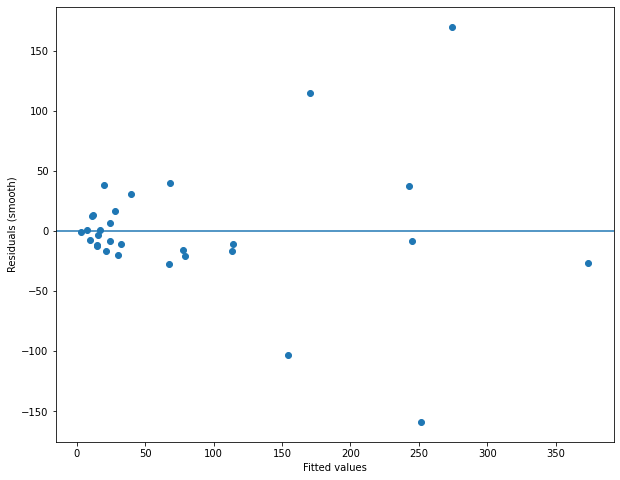

In [27]:
beta_0 = gam_smooth.coef_[-1]
print("Intercept estimate:", beta_0)
fitted = gam_smooth.predict(X)
residuals_smooth = y - fitted
plt.figure(figsize=(10,8))
plt.scatter(fitted, residuals_smooth)
plt.xlabel('Fitted values')
plt.ylabel('Residuals (smooth)')
plt.axhline(0)
plt.show()

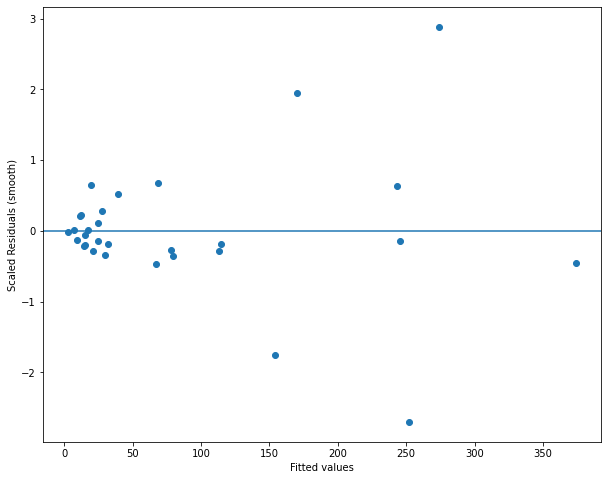

In [28]:
#it looks a bit like a funnel which indicates heteroscedasticity
#we can try it with scaled residuals
scaled_residuals = gam_smooth.deviance_residuals(X,y, scaled = True)
plt.figure(figsize=(10,8))
plt.scatter(fitted, scaled_residuals)
plt.xlabel('Fitted values')
plt.ylabel('Scaled Residuals (smooth)')
plt.axhline(0)
plt.show()

C:\Users\Mimi\anaconda3\Lib\site-packages\pygam\pygam.py:2859: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y = y.ravel()


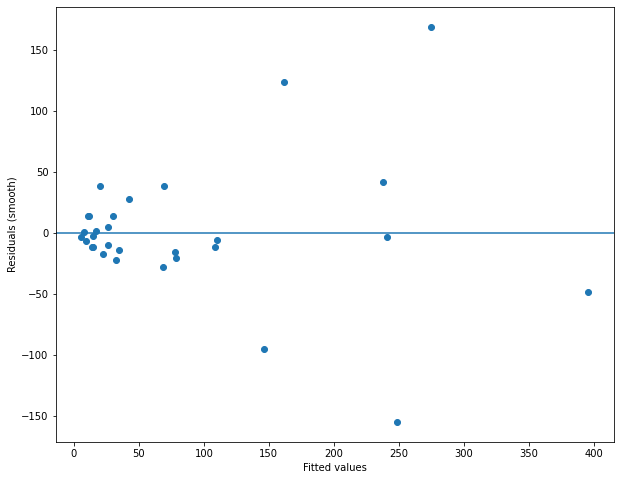

In [29]:
#let's try other GAM
gam_poisson = PoissonGAM(s(0, n_splines = 5)).fit(X, y)
fitted = gam_poisson.predict(X)
residuals_poisson = y - fitted
plt.figure(figsize=(10,8))
plt.scatter(fitted, residuals_poisson)
plt.xlabel('Fitted values')
plt.ylabel('Residuals (smooth)')
plt.axhline(0)
plt.show()

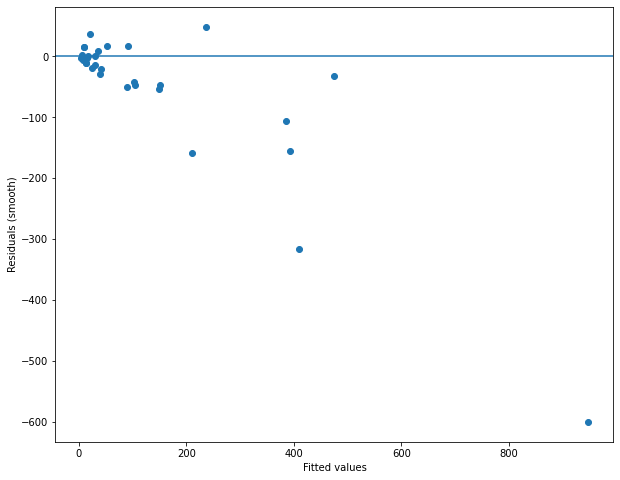

In [30]:
#let's try other GAM
gam_inv = InvGaussGAM(s(0, n_splines = 5)).fit(X, y)
fitted = gam_inv.predict(X)
residuals_inv = y - fitted
plt.figure(figsize=(10,8))
plt.scatter(fitted, residuals_inv)
plt.xlabel('Fitted values')
plt.ylabel('Residuals (smooth)')
plt.axhline(0)
plt.show()

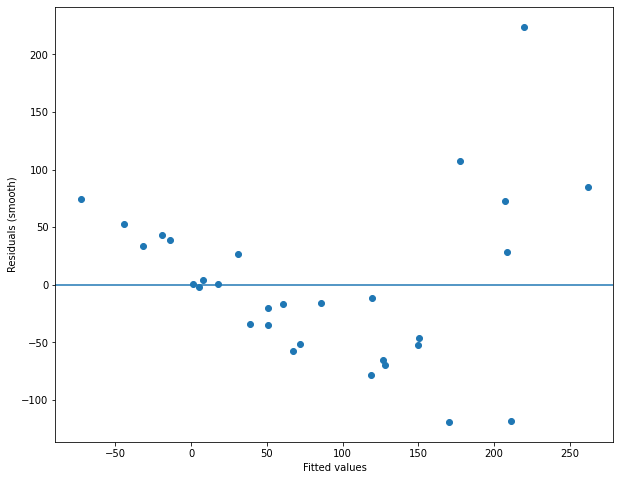

In [31]:
gam_linear = LinearGAM(l(0)).fit(X, y)
fitted = gam_linear.predict(X)
residuals_linear = y - fitted
plt.figure(figsize=(10,8))
plt.scatter(fitted, residuals_linear)
plt.xlabel('Fitted values')
plt.ylabel('Residuals (smooth)')
plt.axhline(0)
plt.show()

In [32]:
#try multiple predictors in GAM
temp_data = pd.read_csv("underwater_temperature.csv", encoding="latin1")
temp_data.head()
data = temp_data.copy()

In [33]:
temp_data.columns

Index(['ID', 'Site', 'Latitude', 'Longitude', 'Date', 'Time', 'Temp (°C)',
       'Depth'],
      dtype='object')

In [34]:
for col in temp_data.columns:
    print(temp_data[col].value_counts())

ID
408638    1
1         1
2         1
3         1
4         1
         ..
19        1
18        1
17        1
16        1
15        1
Name: count, Length: 408638, dtype: int64
Site
Ilha Deserta                   86152
Ilha da Galé                   50891
Tamboretes                     50798
Parcel do Xavier (Alalunga)    49690
Moleques do Sul                42467
Parcel da Pombinha             41438
lha do Xavier                  33773
Ilha do Coral                  28942
Ilha dos Lobos                 24487
Name: count, dtype: int64
Latitude
27.2706    86152
27.1719    50891
27.6111    49690
27.8454    42467
27.1804    41438
27.6092    33773
27.9354    28942
26.3884    28446
28.4461    24487
26.3679    22352
Name: count, dtype: int64
Longitude
48.3310    86152
48.4080    50891
48.3882    49690
48.4318    42467
48.4097    41438
48.3858    33773
48.5451    28942
48.5250    28446
48.7087    24487
48.5220    22352
Name: count, dtype: int64
Date
2013/11/18    938
2013/11/20    936
2013/11

In [35]:
group_by_date = temp_data.groupby(["Date", "Site"], as_index = False).agg(
          Temp=("Temp (°C)", "mean"),
          Daily_min_temp=("Temp (°C)", "min"),
          Daily_max_temp=("Temp (°C)", "max"),
          Observations=("Temp (°C)", "size"),
          Depth = ("Depth", "mean"),
      )
group_by_date.head()

,Date,Site,Temp,Daily_min_temp,Daily_max_temp,Observations,Depth
0,2012/12/17,Tamboretes,25.679765,22.142,26.781,81,8.802469
1,2012/12/18,Moleques do Sul,21.792656,21.378,22.429,32,5.000000
2,2012/12/18,Tamboretes,25.711146,22.142,26.977,144,8.500000
3,2012/12/19,Moleques do Sul,22.871639,20.996,23.677,72,5.000000
4,2012/12/19,Tamboretes,24.904347,21.091,27.370,144,8.500000


In [36]:
group_by_date['Date'] = pd.to_datetime(group_by_date['Date'])

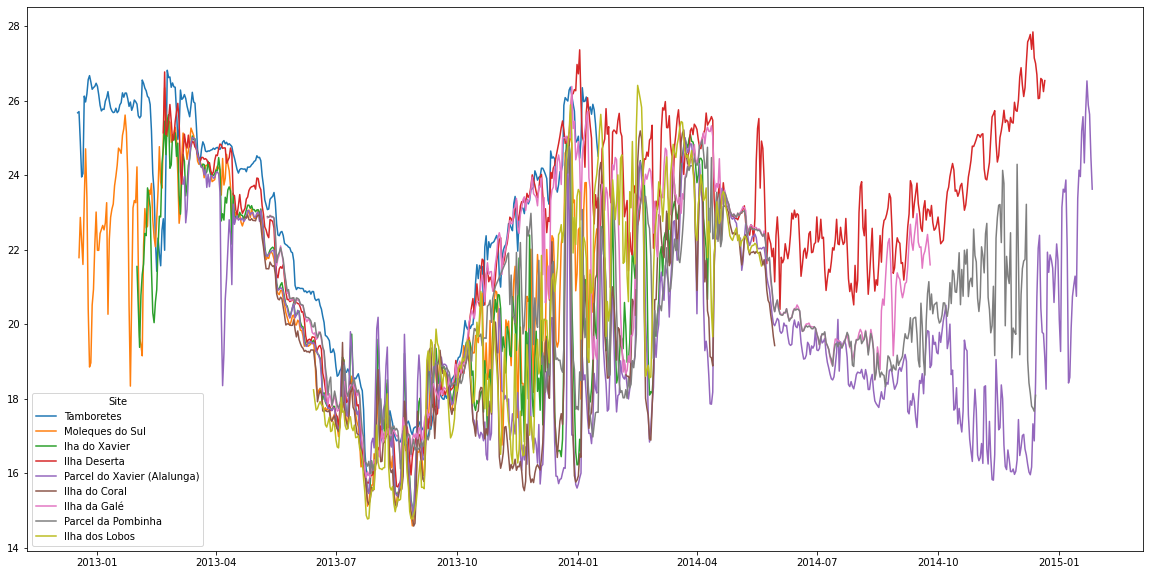

In [37]:
plt.figure(figsize=(20,10))
for site in group_by_date['Site'].unique():
    site_data = group_by_date[group_by_date['Site']==site]
    plt.plot(site_data['Date'], site_data['Temp'], label=site)
plt.legend(title="Site")
plt.show()
    

In [38]:
#clean the data 
train_data = data.iloc[:-672].copy()
train_data.head()

,ID,Site,Latitude,Longitude,Date,Time,Temp (°C),Depth
0,1,Ilha Deserta,27.2706,48.331,2013/02/20,11:40:02,24.448,12.0
1,2,Ilha Deserta,27.2706,48.331,2013/02/20,12:00:03,24.448,12.0
2,3,Ilha Deserta,27.2706,48.331,2013/02/20,12:20:04,24.545,12.0
3,4,Ilha Deserta,27.2706,48.331,2013/02/20,12:40:05,24.448,12.0
4,5,Ilha Deserta,27.2706,48.331,2013/02/20,13:00:06,24.351,12.0


In [39]:
#Temp missing values
train_data.isna().sum()

ID           0
Site         0
Latitude     0
Longitude    0
Date         0
Time         0
Temp (°C)    4
Depth        0
dtype: int64

In [40]:
test_data = data.iloc[-672:].copy()

In [41]:
train_data["DateTime"] = pd.to_datetime(
    train_data["Date"].astype(str) + " " + train_data["Time"].astype(str)
)

In [44]:
train_data['Temp'] = train_data['Temp (°C)']

In [45]:
hourly = (
    train_data
    .set_index("DateTime")
    .groupby("Site")[["Temp", "Depth"]]
    .resample("1h")
    .last()
    .reset_index()
)

In [46]:
hourly.isna().sum()

Site          0
DateTime      0
Temp        183
Depth       183
dtype: int64

In [47]:
hourly.head()

,Site,DateTime,Temp,Depth
0,Ilha Deserta,2013-02-20 11:00:00,24.448,12.0
1,Ilha Deserta,2013-02-20 12:00:00,24.448,12.0
2,Ilha Deserta,2013-02-20 13:00:00,25.125,5.0
3,Ilha Deserta,2013-02-20 14:00:00,25.125,5.0
4,Ilha Deserta,2013-02-20 15:00:00,25.222,5.0


In [48]:
missing_summary = hourly.groupby("Site")[["Temp", "Depth"]].apply(
    lambda x: x.isna().sum()
)


In [49]:
missing_summary

,Temp,Depth
Site,,
Ilha Deserta,0,0
Ilha da Galé,0,0
Ilha do Coral,0,0
Ilha dos Lobos,0,0
Moleques do Sul,0,0
Parcel da Pombinha,183,183
Parcel do Xavier (Alalunga),0,0
Tamboretes,0,0
lha do Xavier,0,0


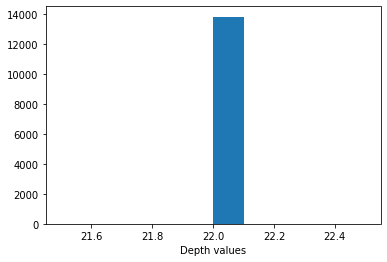

Max 22.0
Min 22.0


In [50]:
missing_site = hourly[hourly['Site']=='Parcel da Pombinha']
plt.hist(missing_site['Depth'])
plt.xlabel('Depth values')
plt.show()
print('Max', missing_site['Depth'].max())
print('Min', missing_site['Depth'].min())

In [51]:
#we can put missing depth be equal to 22 
missing = missing_site[missing_site['Temp'].isna()]
missing.columns

Index(['Site', 'DateTime', 'Temp', 'Depth'], dtype='object')

In [52]:
missing = missing_site[missing_site['Temp'].isna()].copy()
missing = missing.sort_values('DateTime')

# Example: readings expected every 1 hour
expected_freq = pd.Timedelta('1h')

# Start a new gap whenever timestamps are not consecutive
missing['gap_id'] = (
    missing['DateTime'].diff().gt(expected_freq)
).cumsum()

gaps = (
    missing.groupby('gap_id')
    .agg(
        start=('DateTime', 'min'),
        end=('DateTime', 'max'),
        missing_count=('DateTime', 'size')
    )
    .reset_index(drop=True)
)

gaps

,start,end,missing_count
0,2013-10-30 20:00:00,2013-11-07 10:00:00,183


In [53]:
min_date = np.min(missing['DateTime'])
min_date

Timestamp('2013-10-30 20:00:00')

In [54]:
max_date = np.max(missing['DateTime'])
max_date

Timestamp('2013-11-07 10:00:00')

In [55]:
training_data = missing_site[~missing_site['Temp'].isna()]

print(len(training_data))
print(len(missing))

13814
183


In [56]:
print(len(missing_site))

13997


In [57]:
train = (
    training_data.rename(columns={"DateTime": "ds", "Temp": "y"})
)

model = Prophet(
    daily_seasonality=False,  # replaced with custom daily pattern below
    weekly_seasonality=True,
    yearly_seasonality="auto",
    changepoint_prior_scale=0.05,
    interval_width=0.95
)

# Period is expressed in days; period=1 means a 24-hour cycle
model.add_seasonality(
    name="daily",
    period=1,
    fourier_order=8
)

model.fit(train)

18:41:09 - cmdstanpy - INFO - Chain [1] start processing
18:41:16 - cmdstanpy - INFO - Chain [1] done processing


In [58]:
missing_dates = (
    missing
    .rename(columns={"DateTime": "ds"})
)

predictions = model.predict(missing_dates)[
    ["ds", "yhat", "yhat_lower", "yhat_upper", "trend", "daily", "weekly"]
]

predictions

,ds,yhat,yhat_lower,yhat_upper,trend,daily,weekly
0,2013-10-30 20:00:00,20.376727,17.993063,22.676658,20.390581,0.051605,-0.065458
1,2013-10-30 21:00:00,20.318444,17.936816,22.710235,20.392525,-0.002909,-0.071172
2,2013-10-30 22:00:00,20.289215,17.684792,22.813179,20.394470,-0.028451,-0.076804
3,2013-10-30 23:00:00,20.287645,17.711275,22.712828,20.396414,-0.026448,-0.082321
4,2013-10-31 00:00:00,20.280132,17.778625,22.857211,20.398359,-0.030537,-0.087690
...,...,...,...,...,...,...,...
178,2013-11-07 06:00:00,20.629340,18.170179,23.049241,20.736705,0.007871,-0.115236
179,2013-11-07 07:00:00,20.596106,17.997796,23.054190,20.738650,-0.023703,-0.118841
180,2013-11-07 08:00:00,20.613205,18.000879,23.055561,20.740594,-0.005269,-0.122121
181,2013-11-07 09:00:00,20.629428,18.348925,22.979805,20.742539,0.011957,-0.125068


In [59]:
mask = (
    hourly["Site"].eq("Parcel da Pombinha")
    & hourly["Temp"].isna()
)

assert mask.sum() == len(predictions)

hourly.loc[mask, "Temp"] = predictions["yhat"].to_numpy()

In [60]:
hourly.columns

Index(['Site', 'DateTime', 'Temp', 'Depth'], dtype='object')

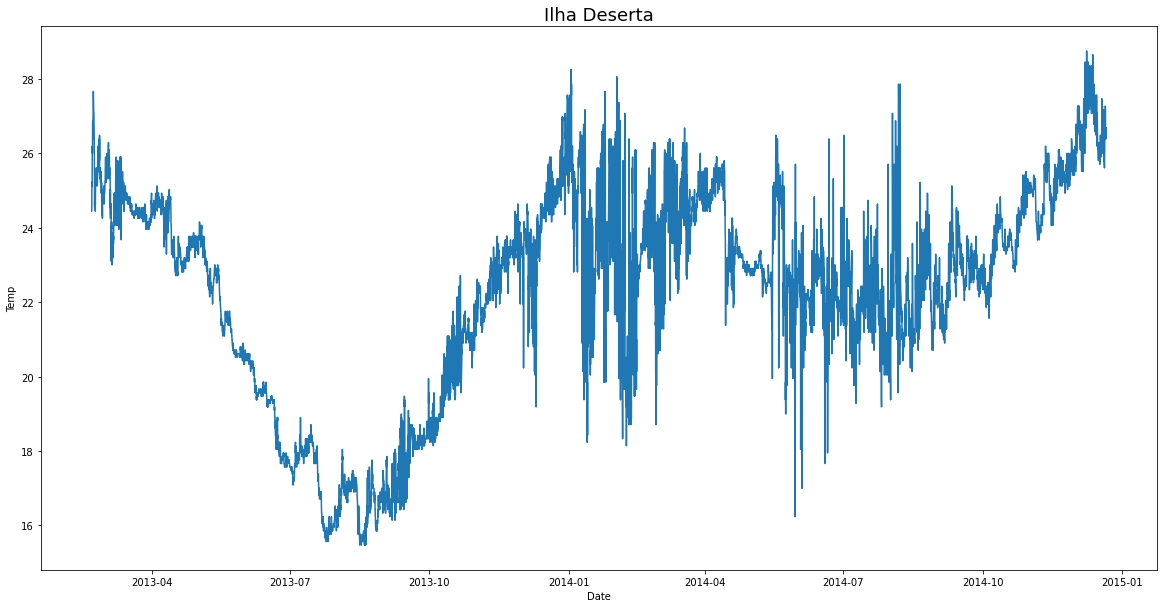


Ilha Deserta - Original
ADF Statistic: -2.5032
ADF p-value: 0.1147
ADF Interpretation: Non-Stationary
KPSS Statistic: 4.9332
KPSS p-value: 0.0100
KPSS Interpretation: Non-Stationary


C:\Users\Mimi\AppData\Local\Temp\ipykernel_20248\2950674830.py:43: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  statistic, p_value, lags, critical_values = kpss(series, regression="c", nlags="auto")


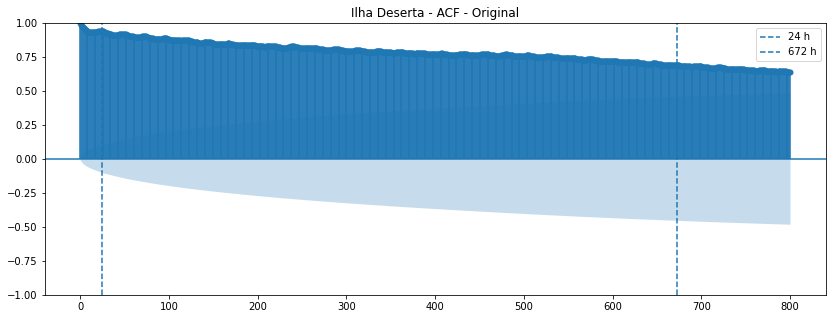


Ilha Deserta - Diff 1
ADF Statistic: -25.2462
ADF p-value: 0.0000
ADF Interpretation: Stationary
KPSS Statistic: 0.0806
KPSS p-value: 0.1000
KPSS Interpretation: Stationary


C:\Users\Mimi\AppData\Local\Temp\ipykernel_20248\2950674830.py:43: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, lags, critical_values = kpss(series, regression="c", nlags="auto")


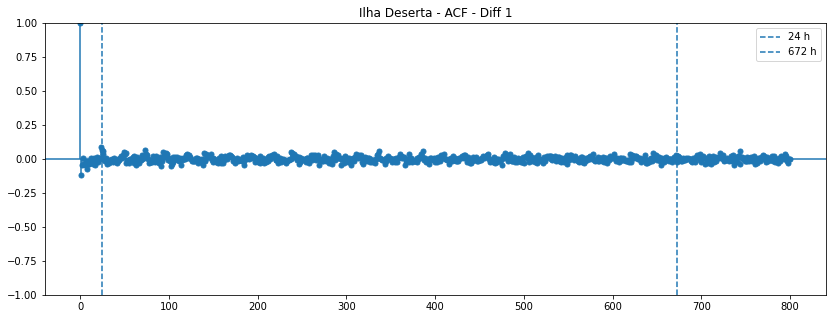


Ilha Deserta - Diff 24
ADF Statistic: -20.2549
ADF p-value: 0.0000
ADF Interpretation: Stationary
KPSS Statistic: 0.1350
KPSS p-value: 0.1000
KPSS Interpretation: Stationary


C:\Users\Mimi\AppData\Local\Temp\ipykernel_20248\2950674830.py:43: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, lags, critical_values = kpss(series, regression="c", nlags="auto")


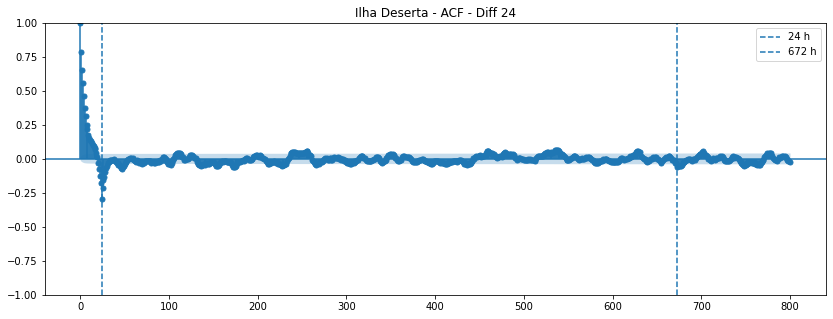


Ilha Deserta - Diff 672
ADF Statistic: -5.7489
ADF p-value: 0.0000
ADF Interpretation: Stationary
KPSS Statistic: 2.5857
KPSS p-value: 0.0100
KPSS Interpretation: Non-Stationary


C:\Users\Mimi\AppData\Local\Temp\ipykernel_20248\2950674830.py:43: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  statistic, p_value, lags, critical_values = kpss(series, regression="c", nlags="auto")


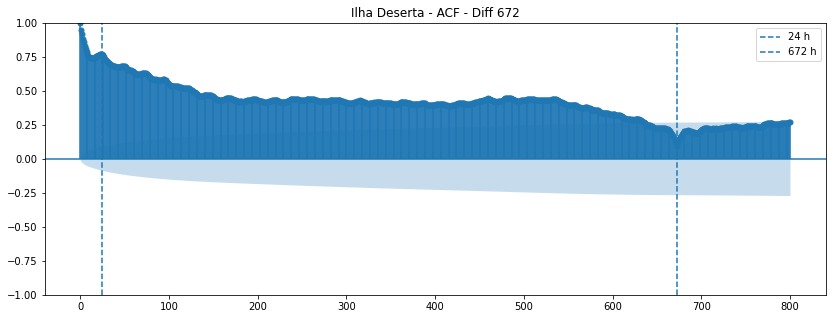

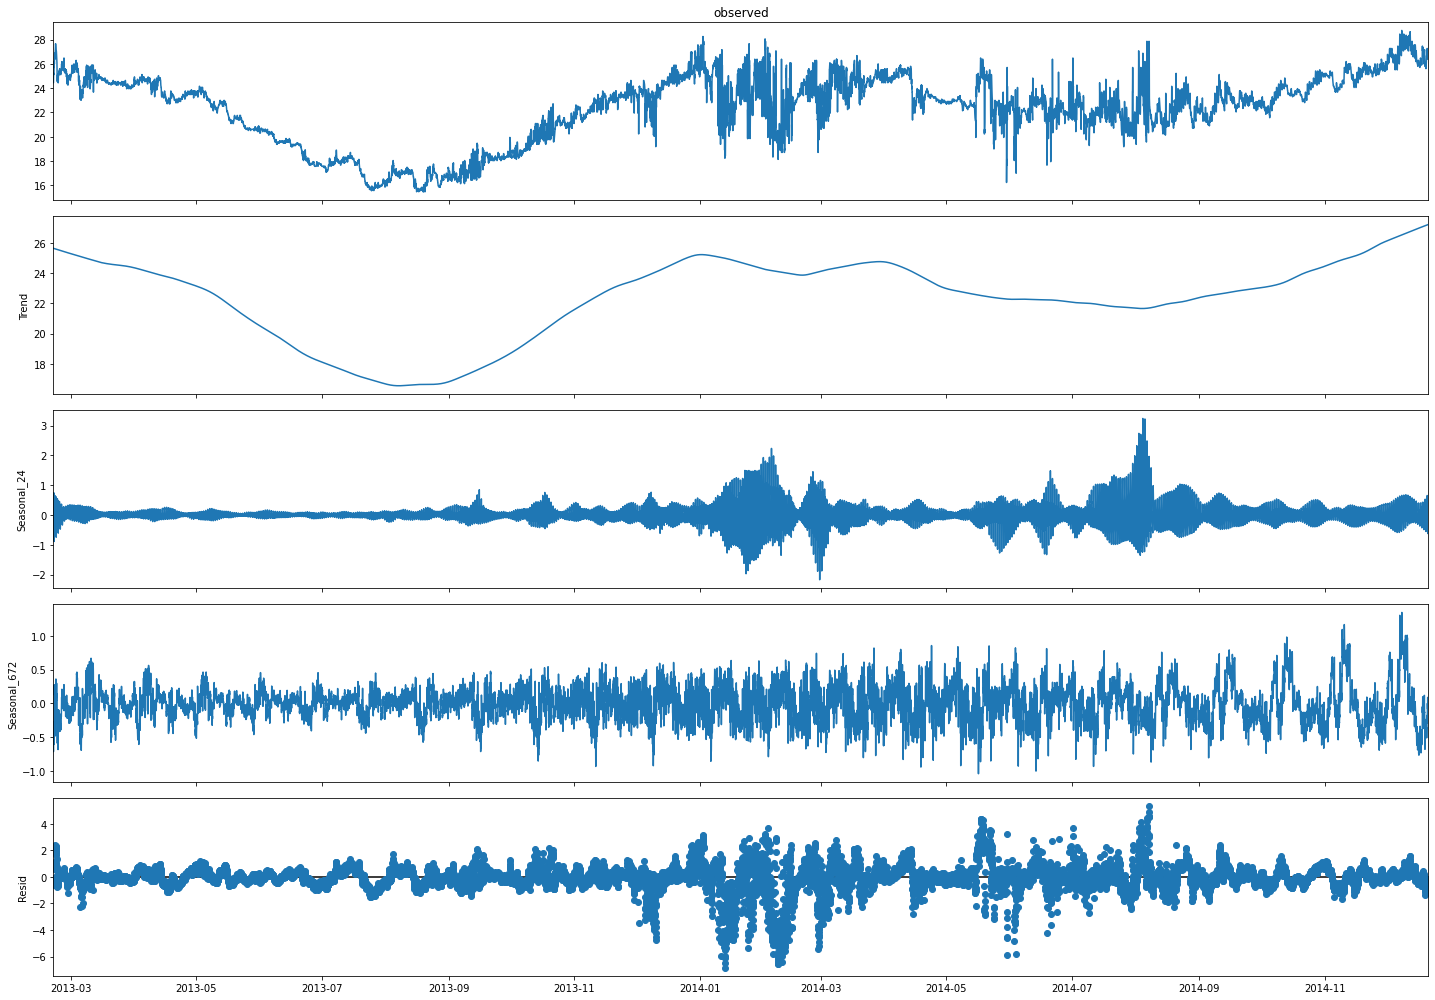

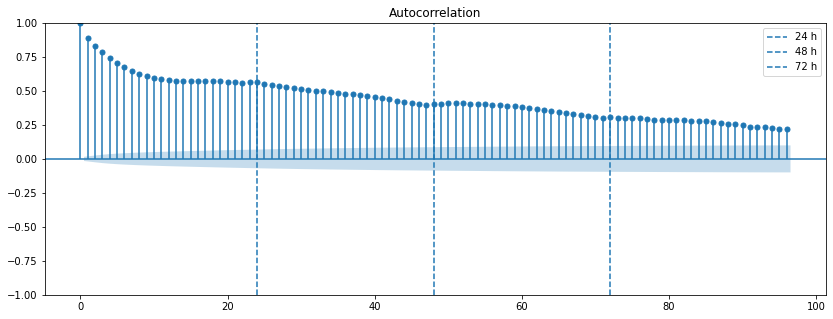

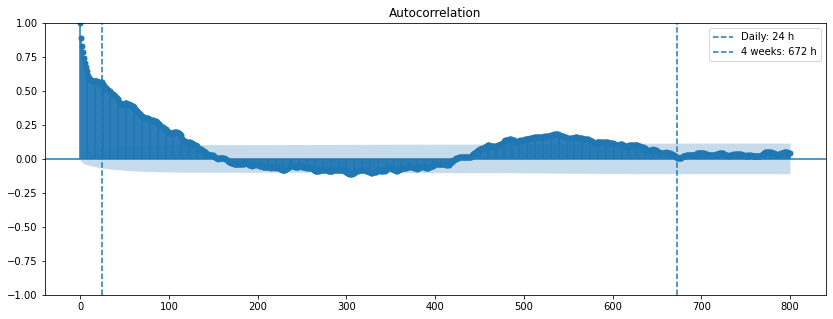

          lb_stat  lb_pvalue
24  156300.907259        0.0


C:\Users\Mimi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\Mimi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [ ]:
#plot each site separately
#look for stationarity and explore seasonality

sites = hourly['Site'].unique()
colors = plt.cm.tab10.colors

for i, site in enumerate(sites):
    plt.figure(figsize=(20,10))
    
    site_data = hourly[hourly['Site']==site].copy()
    site_data["DateTime"] = pd.to_datetime(site_data["DateTime"])
    site_data = site_data.set_index("DateTime")
    
    plt.plot(site_data.index, site_data['Temp'], color=colors[i % len(colors)])
    plt.xlabel('Date')
    plt.ylabel('Temp')
    plt.title(site, fontsize=18)
    plt.show()

    site_data["Temp Diff 1"] = site_data["Temp"].diff(1)
    site_data["Temp Diff 24"] = site_data["Temp"].diff(24)
    site_data["Temp Diff 672"] = site_data["Temp"].diff(672)
    
    series_to_test = {
        "Original": site_data["Temp"],
        "Diff 1": site_data["Temp Diff 1"],
        "Diff 24": site_data["Temp Diff 24"],
        "Diff 672": site_data["Temp Diff 672"],
    }

    for name, series in series_to_test.items():
        series = series.dropna()

        print("\n" + "=" * 70)
        print(f"{site} - {name}")
        print("=" * 70)

        result_adf = adfuller(series)
        print(f"ADF Statistic: {result_adf[0]:.4f}")
        print(f"ADF p-value: {result_adf[1]:.4f}")
        print("ADF Interpretation:", "Stationary" if result_adf[1] < 0.05 else "Non-Stationary")

        statistic, p_value, lags, critical_values = kpss(series, regression="c", nlags="auto")
        print(f"KPSS Statistic: {statistic:.4f}")
        print(f"KPSS p-value: {p_value:.4f}")
        print("KPSS Interpretation:", "Stationary" if p_value >= 0.05 else "Non-Stationary")

        fig, ax = plt.subplots(figsize=(14, 5))
        plot_acf(series, lags=min(800, len(series)//2 - 1), ax=ax)
        ax.axvline(24, linestyle="--", label="24 h")
        ax.axvline(672, linestyle="--", label="672 h")
        ax.set_title(f"{site} - ACF - {name}")
        ax.legend()
        plt.show()

    mstl = MSTL(site_data['Temp'], periods=(24, 672), stl_kwargs={"robust": True})
    result = mstl.fit()
    fig = result.plot()
    fig.set_size_inches(20, 14)
    plt.tight_layout()
    plt.show()

    trend = result.trend
    seasonal = result.seasonal
    remainder = result.resid

    fig, ax = plt.subplots(figsize=(14, 5))
    plot_acf(remainder, lags=96, ax=ax)

    ax.axvline(24, linestyle="--", label="24 h")
    ax.axvline(48, linestyle="--", label="48 h")
    ax.axvline(72, linestyle="--", label="72 h")

    ax.legend()
    plt.show()

    fig, ax = plt.subplots(figsize=(14, 5))
    plot_acf(remainder, lags=800, ax=ax)

    ax.axvline(24, linestyle="--", label="Daily: 24 h")
    ax.axvline(672, linestyle="--", label="4 weeks: 672 h")

    ax.legend()
    plt.show()

    lb = acorr_ljungbox(remainder,lags=[24, ], return_df=True)
    print(lb)


    y_train = site_data['Temp'].iloc[:-672]
    X_train = site_data[['Depth']].iloc[:-672]

    y_test = site_data['Temp'].iloc[-672:]
    X_test = site_data[['Depth']].iloc[-672:]
   
    
    sarimax_model = SARIMAX(y_train, exog = X_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 24)).fit()
    forecast = sarimax_model.forecast(steps=672, exog=X_test)

    residuals = y_test - forecast
    
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, residuals, alpha=0.6)
    plt.axhline(0, linestyle='--')

    plt.xlabel('Predicted Temperature')
    plt.ylabel('Residual (Actual - Predicted)')
    plt.title('Residuals vs Predicted Values')

    plt.show()
    #let's try to resample by mean values
    daily_mean = site_data['Temp'].resample("D").mean().dropna()
    weekly_mean = site_data['Temp'].resample("W").mean().dropna()
    monthly_mean = site_data['Temp'].resample("MS").mean().dropna()
    
    daily_mean.plot(figsize=(20, 10), title="Daily Mean Temperature", color='tab:olive')
    plt.ylabel("Temp")
    plt.show()
    
    mstl_daily = MSTL(daily_mean, periods=[7, 91]).fit()
    fig = mstl_daily.plot()
    fig.set_size_inches(20, 14)
    plt.tight_layout()
    plt.show()


    weekly_mean.plot(figsize=(20, 10), title="Weekly Mean Temperature", color='tab:purple')
    plt.ylabel("Temp")
    plt.show()
    mstl_weekly = MSTL(weekly_mean, periods=[4, 12, 26, 52]).fit()
    fig_w = mstl_weekly.plot()
    fig_w.set_size_inches(20, 14)
    plt.tight_layout()
    plt.show()



    #the strongest pattern is visible in weekly seasonal 4 ( meaning 4 weeks )
    
